<a href="https://colab.research.google.com/github/matinbyrml/xai/blob/main/Global_post_hoc_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Global Post-hoc Explainability
**Teaching assistant** : Eleonora Poeta (eleonora.poeta@polito.it)

---

This lab covers three **global post-hoc** explainability techniques applied to black-box classifiers on the Titanic dataset:

| Technique | What it explains |
|---|---|
| **Permutation Feature Importance** | How much each feature contributes to model performance |
| **Partial Dependence Plot (PDP)** | Marginal effect of one (or two) features on the predicted outcome |
| **Global Surrogate Models** | A white-box model that approximates a black-box model's predictions |

**Guide:**
- ⚙️ Data preprocessing (Titanic)
- 🔀 Permutation Feature Importance
- 📉 Partial Dependence Plots
- 🪞 Global Surrogate Models


## ⚙️ Data Preprocessing (~10 min)

We are using the **Titanic** dataset loaded directly from OpenML.
This section walks you through the full preprocessing pipeline: loading, splitting, imputing, encoding, and scaling.

> 💡 Apply the same good habits from Lab 0: always fit transformations on the **training set only**, then apply them to the test set!


### ⚙️ Step 1 — Imports & Load

In [ ]:
# If your dataset is stored on Google Drive, mount the drive before reading it
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression as LR_sklearn
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded")

✅ Libraries loaded


### ⚙️ Step 2 — Load the Titanic Dataset

The [Titanic dataset](https://www.kaggle.com/c/titanic) contains passenger information and whether they survived.
We want to predict the column **`survived`** (0 = no, 1 = yes).


In [3]:
# Load dataset from OpenML
df, y = fetch_openml('titanic', version=1, as_frame=True, parser='auto', return_X_y=True)
df["survived"] = y

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1309, 14)


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [4]:
# Quick overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
 13  survived   1309 non-null   category
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


In [5]:
# Class balance — important for choosing metrics!
print("Class distribution:")
print(df["survived"].value_counts())
print(f"\nImbalance ratio: {df['survived'].value_counts()[0]/df['survived'].value_counts()[1]:.2f}:1")

Class distribution:
survived
0    809
1    500
Name: count, dtype: int64

Imbalance ratio: 1.62:1


/tmp/ipykernel_2274/912207974.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nImbalance ratio: {df['survived'].value_counts()[0]/df['survived'].value_counts()[1]:.2f}:1")
/tmp/ipykernel_2274/912207974.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nImbalance ratio: {df['survived'].value_counts()[0]/df['survived'].value_counts()[1]:.2f}:1")


### ⚙️ Step 3 — Stratified Train / Test Split

> 🔑 **Key reminder:** split *before* any transformation. Fitting scalers or imputers on the full dataset causes **data leakage**.


In [6]:
#### START CODE HERE ####
# Split 80% train / 20% test, shuffle=True, random_state=42, stratify by 'survived'
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=True, random_state=42, stratify=df['survived'])
#### END CODE HERE ####

print(f"Train: {len(df_train)} samples | Test: {len(df_test)} samples")
print("\nTrain class distribution:")
print(df_train["survived"].value_counts())

Train: 1047 samples | Test: 262 samples

Train class distribution:
survived
0    647
1    400
Name: count, dtype: int64


### ⚙️ Step 4 — Handle Missing Values

> 🔑 **Key reminder:** compute statistics (mean, median…) on the **training set only**, then apply to both sets.


In [7]:
# Count NaN per column
nan_train = df_train.isna().sum()
nan_test  = df_test.isna().sum()

print("Missing values — Train:")
print(nan_train[nan_train > 0])
print("\nMissing values — Test:")
print(nan_test[nan_test > 0])

Missing values — Train:
age          209
fare           1
cabin        822
boat         658
body         955
home.dest    450
dtype: int64

Missing values — Test:
age           54
cabin        192
embarked       2
boat         165
body         233
home.dest    114
dtype: int64


In [9]:
#### START CODE HERE ####
# Fill 'age' NaN with the TRAINING mean
df_train['age'].fillna(df_train['age'].mean(), inplace=True)
df_test['age'].fillna(df_train['age'].mean(), inplace=True)

# Fill 'fare' NaN with the TRAINING median
df_train['fare'].fillna(df_train['fare'].median(), inplace=True)
df_test['fare'].fillna(df_train['fare'].median(), inplace=True)

# Drop columns with too many missing values or that are not useful
cols_to_drop = ['boat', 'body', 'home.dest', 'cabin', 'ticket', 'name']
df_train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')
#### END CODE HERE ####

# Fill remaining categorical NaN with the most frequent value
for col in ['embarked']:
    most_freq = df_train[col].mode()[0]
    df_train[col].fillna(most_freq, inplace=True)
    df_test[col].fillna(most_freq, inplace=True)

print(f"Remaining NaN — Train: {df_train.isna().sum().sum()} | Test: {df_test.isna().sum().sum()}")

Remaining NaN — Train: 0 | Test: 0


/tmp/ipykernel_2274/1796465278.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['age'].fillna(df_train['age'].mean(), inplace=True)
/tmp/ipykernel_2274/1796465278.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

### ⚙️ Step 5 — Encoding & Scaling

> 🔑 **Key reminder:** ML models need numbers. Categorical features must be encoded. Scaling is important for distance-based models and regularised models.


In [10]:
df_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
999,3,female,29.604316,0,0,7.7500,Q,1
392,2,female,24.000000,1,0,27.7208,C,1
628,3,female,11.000000,4,2,31.2750,S,0
1165,3,male,25.000000,0,0,7.2250,C,0
604,3,female,16.000000,0,0,7.6500,S,1


In [11]:
# Label-encode binary categorical column 'sex'
le = LabelEncoder()
le.fit(df_train['sex'])
df_train['sex'] = le.transform(df_train['sex'])
df_test['sex']  = le.transform(df_test['sex'])

# One-hot encode 'embarked' (S, C, Q)
df_train = pd.get_dummies(df_train, columns=['embarked'], drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=['embarked'], drop_first=True)

# Align columns (test may be missing a column if a category is absent)
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

print("Columns after encoding:", df_train.columns.tolist())

Columns after encoding: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived', 'embarked_Q', 'embarked_S']


In [12]:
feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
                'embarked_Q', 'embarked_S']

X_train = df_train[feature_cols].astype(float)
X_test  = df_test[feature_cols].astype(float)

y_train = df_train['survived'].astype(int)
y_test  = df_test['survived'].astype(int)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test  = scaler.transform(X_test)        # only transform on test

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (1047, 8) | X_test shape: (262, 8)


> ✅ **Preprocessing complete.** Remember the three rules:
> 1. Split *before* fitting any transformer.
> 2. Fit transformers on **train only**, apply to both.
> 3. Encode categoricals before passing to any sklearn estimator.


## Exercise 1 — Permutation Feature Importance 🔀

**Permutation Feature Importance** is a model-agnostic inspection technique that measures how much each feature contributes to model performance.

> A feature is **important** if shuffling its values causes the *model error to increase*. If the model relied on that feature, disrupting it should hurt performance.

**Key advantages:**
- Direct and intuitive interpretation of the model's behaviour
- Fully **model-agnostic** — works with any fitted estimator
- Does **not require retraining** the model

**Main disadvantages:**
- Assumes **feature independence** — correlated features can produce biased importance estimates
- Tightly coupled to the chosen **performance metric**

---

### Your tasks
1. Fit a [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) on the Titanic dataset and inspect its **accuracy** on train and test.

### Exercise 1.1 — Feature Importances
2. Calculate **built-in feature importances** (as in Lab 1).
> * What is the most important feature? Is it categorical or numerical?
> * You can aggregate (via sum) importances of dummy columns for the same original categorical attribute.

### Exercise 1.2 — Permutation Importance
3. Compute [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html).
> * First on the **test set**. What are the most important features?
> * Repeat on the **training set**. Did you get the same result? If not, what does this suggest?

### Exercise 1.3 — Regularisation vs Overfitting
4. Instantiate a second `RandomForestClassifier` with `min_samples_leaf=20`.
> * Repeat permutation importance on both train and test. Has anything changed?
> * What does this tell you about Random Forest overfitting and the `fare` feature?

> ***Hint:*** In the first case, the discrepancy between train and test permutation importance can be explained by overfitting — the RF uses `fare` to memorise training examples.


### 1.1 — Fit & Evaluate

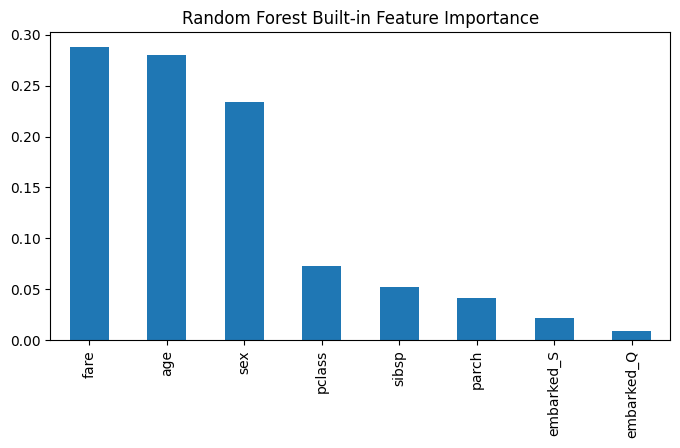

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Fit the Black Box Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 1.1 Built-in Feature Importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).plot.bar(figsize=(8,4))
plt.title("Random Forest Built-in Feature Importance")
plt.show()

### 1.2 — Feature Importances

In [14]:
from sklearn.inspection import permutation_importance

# 1.2 Permutation Importance on TEST set
r_test = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
test_importance = pd.Series(r_test.importances_mean, index=feature_cols)

# Permutation Importance on TRAIN set
r_train = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
train_importance = pd.Series(r_train.importances_mean, index=feature_cols)

# Display them side-by-side
compare_df = pd.DataFrame({'Train Importance': train_importance, 'Test Importance': test_importance})
print(compare_df.sort_values(by='Test Importance', ascending=False))

            Train Importance  Test Importance
sex                 0.238395     1.927481e-01
pclass              0.135053     3.473282e-02
age                 0.179847     8.015267e-03
embarked_Q          0.020057     4.440892e-17
embarked_S          0.088443    -1.908397e-03
fare                0.151576    -2.671756e-03
parch               0.044317    -6.870229e-03
sibsp               0.055683    -1.068702e-02


### 1.3 — Permutation Importance (Test vs Train)

In [15]:
# 1.3 Train a restricted (regularized) Random Forest
rf_regularized = RandomForestClassifier(min_samples_leaf=20, random_state=42)
rf_regularized.fit(X_train, y_train)

# Run Permutation Importance again...
r_test_reg = permutation_importance(rf_regularized, X_test, y_test, n_repeats=10, random_state=42)
test_imp_reg = pd.Series(r_test_reg.importances_mean, index=feature_cols)
print("Regularized Test Importance:\n", test_imp_reg.sort_values(ascending=False))

Regularized Test Importance:
 sex           0.239695
pclass        0.027099
sibsp         0.019084
embarked_S    0.017939
parch         0.013359
age           0.008015
fare          0.001145
embarked_Q    0.000000
dtype: float64


### 1.4 — Regularised Random Forest (`min_samples_leaf=20`)

In [ ]:
#### START CODE HERE ####


#### END CODE HERE ####

## Exercise 2 — Partial Dependence Plots 📉

A **Partial Dependence Plot** (PDP) shows the **marginal effect** of one (or two) features on the predicted outcome of a machine learning model.

- It is a **global method**: it considers *all instances* and describes the global relationship between a feature and the prediction.
- PDPs are easy to visualise and intuitively interpretable.

**Key advantages:**
- Computation is intuitive and the visualisation is easy to read.
- Provides a global view of how a feature influences the prediction.

**Main disadvantages:**
- Assumes **feature independence** — correlated features distort the marginal estimates.
- Only practical for **at most two features** at a time.

---

### Your tasks
1. Instantiate and fit a [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and a [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) on the Titanic dataset.
2. **Evaluate** both models — inspect accuracy on train and test.
3. Print **feature importances** for both models.
4. Generate **PDPs** using [`PartialDependenceDisplay.from_estimator`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html) for both models.


### 2.1 — Fit RF & DT Classifiers

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Fit a simple Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Fit a Random Forest
rf = RandomForestClassifier(min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)

print(f"DT Test Accuracy: {accuracy_score(y_test, dt.predict(X_test)):.3f}")
print(f"RF Test Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.3f}")

DT Test Accuracy: 0.828
RF Test Accuracy: 0.836


In [ ]:
#### START CODE HERE -- Decision Tree ####


#### END CODE HERE ####

### 2.2 — Feature Importances

In [ ]:
#### START CODE HERE -- Feature Importance RF ####


#### END CODE HERE ####

In [ ]:
#### START CODE HERE -- Feature Importance DT ####


#### END CODE HERE ####

### 2.3 — Partial Dependence Plots

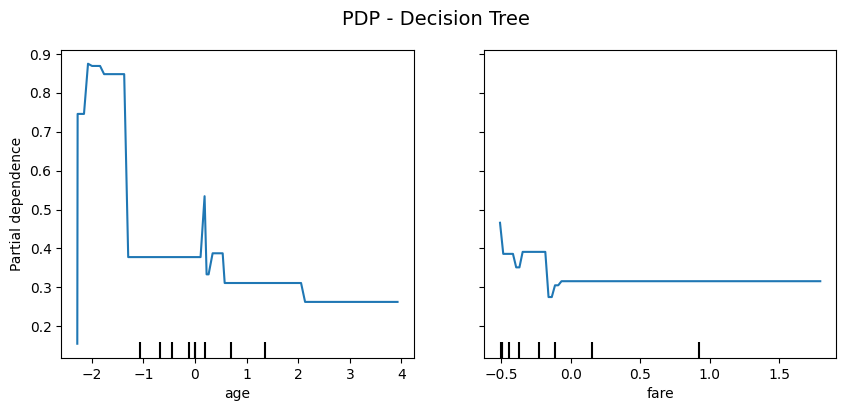

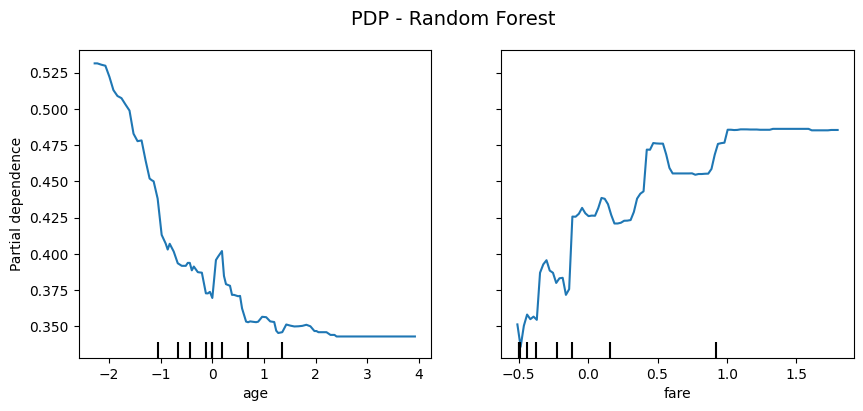

In [17]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Features we want to plot (Indices of Age and Fare from our feature_cols)
features_to_plot = ['age', 'fare']

# 1. PDP for the Decision Tree
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    dt, X_train, features_to_plot, feature_names=feature_cols, ax=ax
)
plt.suptitle("PDP - Decision Tree", fontsize=14)
plt.show()

# 2. PDP for the Random Forest
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    rf, X_train, features_to_plot, feature_names=feature_cols, ax=ax
)
plt.suptitle("PDP - Random Forest", fontsize=14)
plt.show()

In [ ]:
#### START CODE HERE -- PDP Decision Tree ####


#### END CODE HERE ####

## Exercise 3 — Global Surrogate Models 🪞

A **global surrogate model** is an *interpretable* model trained to **approximate** the predictions of a black-box model as accurately as possible.

> The key idea: you don't need to peek inside the black box — only its **prediction function** and a dataset are required.

**How to build a surrogate:**
1. Select a dataset X.
2. Get the **black-box predictions** for X.
3. Choose an **interpretable model type** (linear model, decision tree, …).
4. Train the interpretable model on X using the black-box predictions as labels.
5. Measure how well the surrogate **replicates** the black-box predictions (reconstruction error).

The surrogate is **model-agnostic** — it makes no assumptions about the inner workings of the black-box model.

---

### Your tasks
1. Instantiate and fit a **black-box model**: [`GradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) on the Titanic dataset.

2. Instantiate and fit a **white-box surrogate**: [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) trained on X and the *black-box predictions*.

3. **Evaluate** both models:
> * Calculate `accuracy_score` for both on train and test.
> * Calculate the **reconstruction error** — the loss of fidelity when using black-box predictions to supervise the white-box model.

4. **Inspect the surrogate's coefficients.**

> ***Hint:*** The reconstruction error measures how faithfully the white-box model mimics the black-box — lower error means a more faithful surrogate.


### 3.1 — Train the Black-Box Model

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Train the complex Black-Box model on the real labels
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

# Get the Black-Box's predictions for the training set
# THESE are our new labels for the surrogate!
y_train_pred_gb = gb.predict(X_train)

# 2. Train the simple White-Box model on the Black-Box's predictions!
surrogate_lr = LogisticRegression(random_state=42)
surrogate_lr.fit(X_train, y_train_pred_gb)

LogisticRegression(random_state=42)

### 3.2 — Train the White-Box Surrogate

In [ ]:
#### START CODE HERE ####


#### END CODE HERE ####

### 3.3 — Inspect Surrogate Coefficients

In [19]:
# Evaluate how well the Surrogate matches the Black-Box on the TEST set
y_test_pred_gb = gb.predict(X_test)         # What the Black-Box thinks
y_test_pred_surrogate = surrogate_lr.predict(X_test) # What the Surrogate thinks

# The Fidelity (Accuracy between the two models, NOT reality)
fidelity = accuracy_score(y_test_pred_gb, y_test_pred_surrogate)

print(f"Surrogate Fidelity to Black-Box: {fidelity:.3f} ({fidelity*100}%)")
print(f"Reconstruction Error: {1 - fidelity:.3f}")

Surrogate Fidelity to Black-Box: 0.908 (90.83969465648855%)
Reconstruction Error: 0.092


### 3.4 — Evaluate Both Models

In [20]:
import pandas as pd
import numpy as np

# Extract coefficients from the surrogate
coefs = surrogate_lr.coef_[0]
odds_ratios = np.exp(coefs)

surrogate_explanation = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefs,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

print(surrogate_explanation)

      Feature  Coefficient  Odds Ratio
4       parch     0.083686    1.087287
5        fare     0.083137    1.086690
6  embarked_Q     0.043958    1.044938
7  embarked_S    -0.325590    0.722101
3       sibsp    -0.365003    0.694195
2         age    -0.910068    0.402497
0      pclass    -1.571082    0.207820
1         sex    -2.269424    0.103372


### 3.5 — Reconstruction Error

In [ ]:
#### START CODE HERE ####


#### END CODE HERE ####

### 🔍 Reflection Questions

1. **Permutation Feature Importance:** Why does permutation importance on the *training set* give a different result than on the *test set* for the unconstrained Random Forest? What does `min_samples_leaf=20` change, and why?

2. **PDP:** The PDP shows the *average* marginal effect. If `fare` and `pclass` are correlated, what risk do you run when interpreting each PDP independently? How could you detect this problem?

3. **Surrogate Model:** A high reconstruction error means the white-box model cannot replicate the black-box well. In that case, is the surrogate still a valid explanation of the black-box? What would you do?

4. **General:** All three methods are **post-hoc** and **global**. Can a global explanation mislead you in a specific individual prediction? Give an example using the Titanic context (e.g. first-class women vs third-class men).
